<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab3B_Multiple_Regression_QR_2026_0508.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 3B: Package-Based Multiple Regression and Fault-Tolerant Design

**Date/time:** Friday, 8 May 2026, 16:00  
**Room:** Comp. Lab 1  
**Course:** CS  

This notebook uses the same CSV files as before:

- `AKHU_student_scores_cs_lab3_clean.csv`
- `AKHU_student_scores_cs_lab3_messy.csv`

Today the model comparison uses **multiple linear regression**: more than one predictor column `X` is used to predict `final_score`.

Class structure:

- 20 minutes lecture and guided examples
- 30 minutes practice
- 10 minutes buffer Q&A


## 0. Colab versus VS Code: where are the files?

### Colab

If you upload files using the left file panel, they usually appear in:

```text
/content
```

If you mount Google Drive, a common folder is:

```text
/content/drive/MyDrive/AKHU_labs
```

### VS Code

Open the whole project folder in VS Code. Put the CSV files inside:

```text
data/
```

Then Python should see files such as:

```text
data/AKHU_student_scores_cs_lab3_clean.csv
```

The most useful diagnostic is:

```python
Path.cwd()
```

It tells you the folder where Python is currently running.


In [1]:
from pathlib import Path

print("Current working directory:", Path.cwd())

CANDIDATE_DIRS = [
    Path("data"),                              # VS Code recommended folder
    Path("."),                                 # same folder as this notebook
    Path("/content"),                          # Colab temporary upload folder
    Path("/content/data"),                     # Colab organized data folder
    Path("/content/drive/MyDrive/AKHU_labs"),  # Colab Google Drive folder
]

def find_data_file(filename):
    """Search common Colab and VS Code locations for a CSV file."""
    print("Searching for:", filename)
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        print("  checking", candidate)
        if candidate.exists():
            print("FOUND:", candidate)
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in data/, /content, or /content/drive/MyDrive/AKHU_labs."
    )

# Optional Colab Drive mount:
# from google.colab import drive
# drive.mount('/content/drive')


Current working directory: /content


## 1. Package imports

This lab uses packages because the goal is to practice the **data-analysis workflow**, not to write every regression formula by hand.

Colab usually already has these packages installed. In VS Code, run this in the terminal if imports fail:

```bash
python -m pip install pandas numpy scikit-learn matplotlib
```


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("imports OK")


pandas: 2.2.2
numpy: 2.0.2
imports OK


## 2. Custom exceptions and EAFP style

EAFP means: **try the action first**, then catch the error if it fails.

Custom exceptions make data problems easier to read:

- `DataFileError`: the file cannot be found or opened.
- `MissingColumnError`: a required column is missing.
- `MissingValueError`: a required cell is blank.
- `NumericConversionError`: a value cannot be converted to a number.


In [3]:
class DataError(Exception):
    """Base class for data problems in this lab."""

class DataFileError(DataError):
    """The file cannot be found or opened."""

class MissingColumnError(DataError):
    """A required column is missing."""

class MissingValueError(DataError):
    """A required cell is blank."""

class NumericConversionError(DataError):
    """A value cannot be converted to a number."""

REQUIRED_COLUMNS = [
    "student_id",
    "hours_studied",
    "attendance_rate",
    "assignments_submitted",
    "quiz_average",
    "final_score",
]

NUMERIC_COLUMNS = [
    "hours_studied",
    "attendance_rate",
    "assignments_submitted",
    "quiz_average",
    "final_score",
]


## 3. Fault-tolerant CSV loading with pandas

The function below uses package-based loading (`pd.read_csv`) but still checks for common data problems.

The clean file should pass. The messy file should fail with a readable custom exception.


In [4]:
def load_and_validate_csv(path):
    """Load a CSV file and validate required columns, missing values, and numeric conversion."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError as exc:
        raise DataFileError(f"File not found: {path}") from exc
    except Exception as exc:
        raise DataFileError(f"Could not read CSV file: {path}") from exc

    missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_columns:
        raise MissingColumnError(f"Missing required columns: {missing_columns}")

    if df[REQUIRED_COLUMNS].isna().any().any():
        counts = df[REQUIRED_COLUMNS].isna().sum()
        bad_counts = counts[counts > 0].to_dict()
        raise MissingValueError(f"Missing values found: {bad_counts}")

    for col in NUMERIC_COLUMNS:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception as exc:
            raise NumericConversionError(f"Column {col} contains a value that is not numeric.") from exc

    return df


## 4. Try the messy file first

The messy file is supposed to fail. The purpose is to practice reading the error message.


In [5]:
messy_path = find_data_file("AKHU_student_scores_cs_lab3_messy.csv")

try:
    messy_df = load_and_validate_csv(messy_path)
    print("Messy file passed validation.")
except DataError as exc:
    print(type(exc).__name__ + ":", exc)


Searching for: AKHU_student_scores_cs_lab3_messy.csv
  checking data/AKHU_student_scores_cs_lab3_messy.csv
  checking AKHU_student_scores_cs_lab3_messy.csv
FOUND: AKHU_student_scores_cs_lab3_messy.csv
MissingValueError: Missing values found: {'hours_studied': 1, 'quiz_average': 1}


## 5. Load the clean file

Modeling happens only after the clean file passes validation.


In [6]:
clean_path = find_data_file("AKHU_student_scores_cs_lab3_clean.csv")
df = load_and_validate_csv(clean_path)

print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()


Searching for: AKHU_student_scores_cs_lab3_clean.csv
  checking data/AKHU_student_scores_cs_lab3_clean.csv
  checking AKHU_student_scores_cs_lab3_clean.csv
FOUND: AKHU_student_scores_cs_lab3_clean.csv
Rows: 12
Columns: ['student_id', 'hours_studied', 'attendance_rate', 'assignments_submitted', 'quiz_average', 'final_score']


,student_id,hours_studied,attendance_rate,assignments_submitted,quiz_average,final_score
0,S01,1.5,0.55,4,48,52
1,S02,2.0,0.60,5,50,56
2,S03,2.3,0.66,5,54,59
3,S04,2.7,0.70,6,58,63
4,S05,3.0,0.74,7,62,67


## 6. Quick EDA with pandas

Before modeling, inspect summary statistics and missing values.


In [7]:
print("Missing values per column:")
print(df.isna().sum())

numeric_cols = [
    "hours_studied",
    "attendance_rate",
    "assignments_submitted",
    "quiz_average",
    "final_score",
]

df[numeric_cols].describe().round(3)


Missing values per column:
student_id               0
hours_studied            0
attendance_rate          0
assignments_submitted    0
quiz_average             0
final_score              0
dtype: int64


,hours_studied,attendance_rate,assignments_submitted,quiz_average,final_score
count,12.000,12.000,12.000,12.000,12.000
mean,3.075,0.747,6.833,64.083,68.917
std,0.943,0.112,1.642,10.950,11.082
min,1.500,0.550,4.000,48.000,52.000
25%,2.275,0.675,5.750,56.250,60.500
50%,3.150,0.760,7.000,64.000,69.000
75%,3.850,0.835,8.000,72.500,76.750
max,4.400,0.900,9.000,81.000,87.000


In [8]:
print("Correlation with final_score:")
print(df[numeric_cols].corr()["final_score"].sort_values(ascending=False).round(3))


Correlation with final_score:
final_score              1.000
quiz_average             0.998
hours_studied            0.991
attendance_rate          0.989
assignments_submitted    0.978
Name: final_score, dtype: float64


## 7. EDA plots

These plots show how each predictor relates to `final_score`.


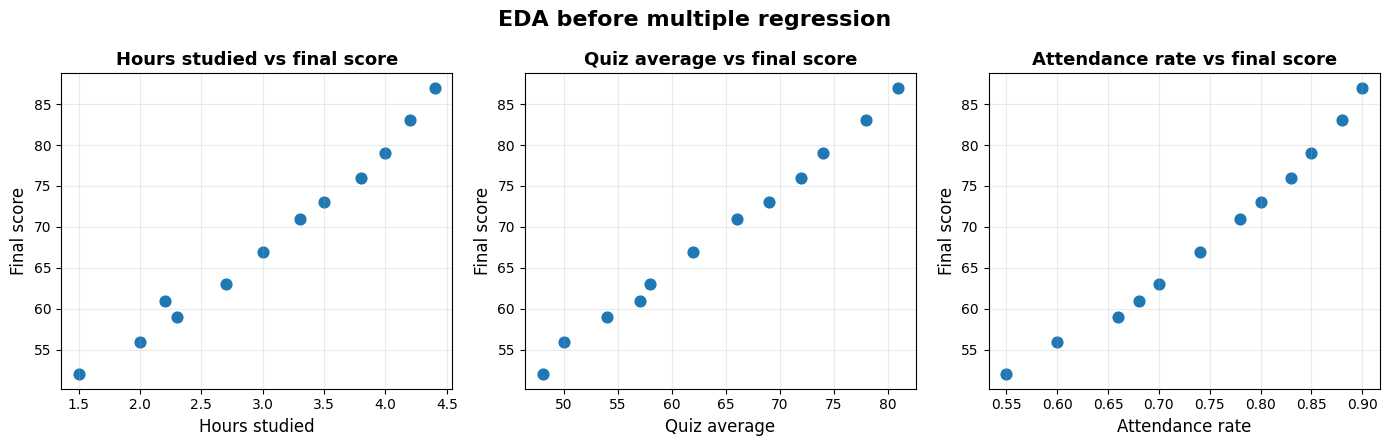

In [9]:
# Plot 1: three predictors versus final score
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_specs = [
    ("hours_studied", "Hours studied"),
    ("quiz_average", "Quiz average"),
    ("attendance_rate", "Attendance rate"),
]

for ax, (col, label) in zip(axes, plot_specs):
    ax.scatter(df[col], df["final_score"], s=60)
    ax.set_title(f"{label} vs final score", fontsize=13, weight="bold")
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Final score", fontsize=12)
    ax.grid(True, alpha=0.25)

fig.suptitle("EDA before multiple regression", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()


## 8. Train/test split

To keep the lab simple and reproducible, use the first 8 rows for training and the last 4 rows for testing.

This is not the only way to split data. It is just a simple beginner-friendly split.


In [10]:
train_df = df.iloc[:8].copy()
test_df = df.iloc[8:].copy()

target = "final_score"
y_train = train_df[target]
y_test = test_df[target]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Test students:", list(test_df["student_id"]))


Training rows: 8
Testing rows: 4
Test students: ['S09', 'S10', 'S11', 'S12']


## 9. Mean baseline model

The mean baseline predicts the same value for every test row:

$$
\hat{y}_{baseline} = \bar{y}_{train}
$$

A regression model should be compared to this simple reference.


In [11]:
def evaluate_predictions(y_true, y_pred):
    """Return MAE, RMSE, and R2 for a set of predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

baseline_value = y_train.mean()
baseline_pred = np.full(len(test_df), baseline_value)

baseline_metrics = evaluate_predictions(y_test, baseline_pred)
print("Baseline prediction value:", round(baseline_value, 3))
print("Baseline metrics: MAE, RMSE, R2 =", tuple(round(v, 3) for v in baseline_metrics))


Baseline prediction value: 64.625
Baseline metrics: MAE, RMSE, R2 = (14.688, 16.264, -1.679)


## 10. Package-based regression models

The main package is `sklearn.linear_model.LinearRegression`.

Today we compare:

1. Mean baseline: no predictors.
2. One-feature regression: `hours_studied`.
3. Multiple regression: `hours_studied` and `quiz_average`.
4. Multiple regression: `hours_studied`, `quiz_average`, and `attendance_rate`.


In [12]:
def fit_and_evaluate_linear_model(train_df, test_df, features, target="final_score"):
    """Fit a package-based linear regression model and return model, predictions, and metrics."""
    model = LinearRegression()
    model.fit(train_df[features], train_df[target])
    predictions = model.predict(test_df[features])
    metrics = evaluate_predictions(test_df[target], predictions)
    return model, predictions, metrics

model_specs = [
    ("Mean baseline", []),
    ("One-feature: hours", ["hours_studied"]),
    ("Multiple: hours + quiz", ["hours_studied", "quiz_average"]),
    ("Multiple: hours + quiz + attendance", ["hours_studied", "quiz_average", "attendance_rate"]),
]

results = []
predictions_by_model = {"Mean baseline": baseline_pred}
models_by_name = {}

for model_name, features in model_specs:
    if features == []:
        mae, rmse, r2 = baseline_metrics
    else:
        model, predictions, (mae, rmse, r2) = fit_and_evaluate_linear_model(train_df, test_df, features, target)
        models_by_name[model_name] = model
        predictions_by_model[model_name] = predictions
    results.append({"model": model_name, "features": ", ".join(features) if features else "none", "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
results_df[["MAE", "RMSE", "R2"]] = results_df[["MAE", "RMSE", "R2"]].round(3)
results_df


,model,features,MAE,RMSE,R2
0,Mean baseline,none,14.688,16.264,-1.679
1,One-feature: hours,hours_studied,2.726,3.022,0.907
2,Multiple: hours + quiz,"hours_studied, quiz_average",1.636,1.910,0.963
3,Multiple: hours + quiz + attendance,"hours_studied, quiz_average, attendance_rate",1.650,1.879,0.964


## 11. Model-comparison plots

Lower MAE and RMSE are better. Higher $R^2$ is better.


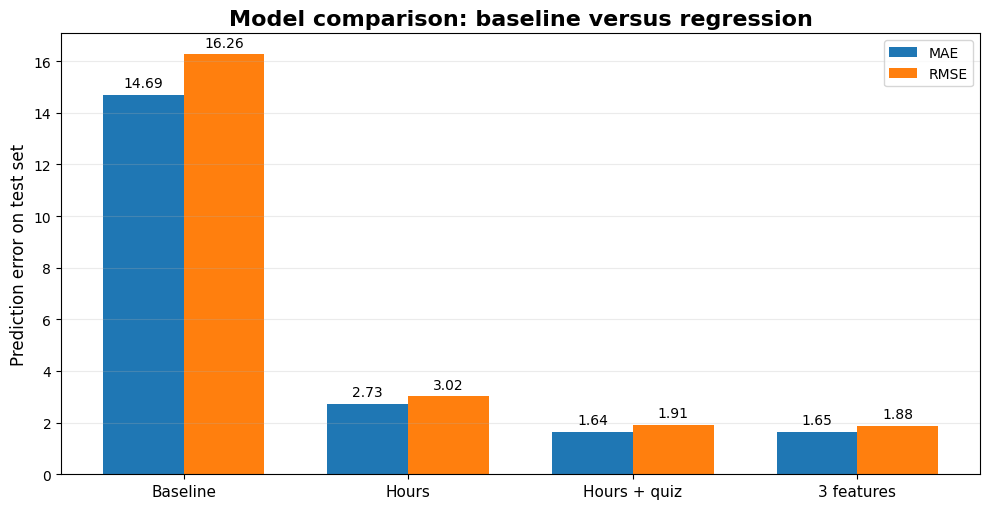

In [13]:
# Plot 2: MAE and RMSE comparison
fig, ax = plt.subplots(figsize=(10, 5.2))
labels = results_df["model"].tolist()
x = np.arange(len(labels))
width = 0.36

mae_values = results_df["MAE"].to_numpy(float)
rmse_values = results_df["RMSE"].to_numpy(float)

bars1 = ax.bar(x - width / 2, mae_values, width, label="MAE")
bars2 = ax.bar(x + width / 2, rmse_values, width, label="RMSE")

ax.set_title("Model comparison: baseline versus regression", fontsize=16, weight="bold")
ax.set_ylabel("Prediction error on test set", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Hours", "Hours + quiz", "3 features"], fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{value:.2f}", ha="center", fontsize=10)

fig.tight_layout()
plt.show()


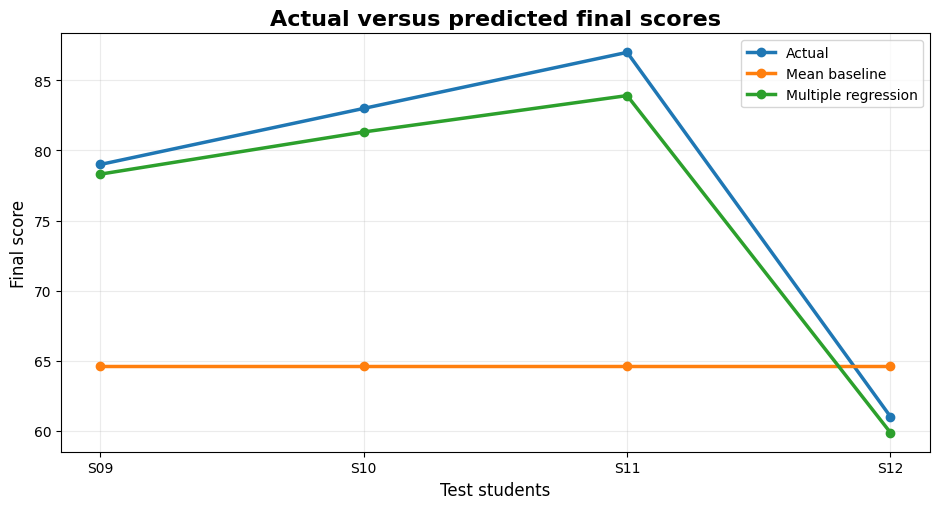

In [14]:
# Plot 3: actual versus predicted values for the test students
selected_model_name = "Multiple: hours + quiz + attendance"
selected_predictions = predictions_by_model[selected_model_name]

test_ids = test_df["student_id"].tolist()
x_positions = np.arange(len(test_ids))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(x_positions, y_test.to_numpy(), marker="o", linewidth=2.5, label="Actual")
ax.plot(x_positions, baseline_pred, marker="o", linewidth=2.5, label="Mean baseline")
ax.plot(x_positions, selected_predictions, marker="o", linewidth=2.5, label="Multiple regression")

ax.set_title("Actual versus predicted final scores", fontsize=16, weight="bold")
ax.set_xlabel("Test students", fontsize=12)
ax.set_ylabel("Final score", fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(test_ids)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


## 12. Read the multiple-regression coefficients

For the three-feature model:

$$
\hat{y} = \beta_0 + \beta_1(	ext{hours studied}) + \beta_2(	ext{quiz average}) + \beta_3(	ext{attendance rate})
$$

A coefficient is part of the fitted prediction formula. It is **not automatically causal**.


In [15]:
best_features = ["hours_studied", "quiz_average", "attendance_rate"]
best_model = models_by_name["Multiple: hours + quiz + attendance"]

coef_df = pd.DataFrame({
    "term": ["intercept"] + best_features,
    "coefficient": [best_model.intercept_] + list(best_model.coef_),
})
coef_df["coefficient"] = coef_df["coefficient"].round(4)
coef_df


,term,coefficient
0,intercept,23.2355
1,hours_studied,6.3379
2,quiz_average,0.4994
3,attendance_rate,-8.5080


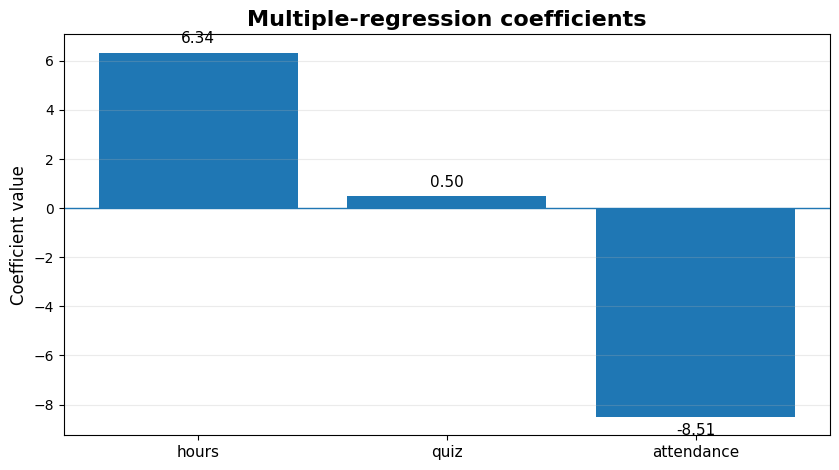

In [16]:
# Plot 4: coefficients
fig, ax = plt.subplots(figsize=(8.5, 4.8))
terms = coef_df.loc[coef_df["term"] != "intercept", "term"].tolist()
coef_values = coef_df.loc[coef_df["term"] != "intercept", "coefficient"].to_numpy(float)

bars = ax.bar(terms, coef_values)
ax.axhline(0, linewidth=1)
ax.set_title("Multiple-regression coefficients", fontsize=16, weight="bold")
ax.set_ylabel("Coefficient value", fontsize=12)
ax.set_xticks(range(len(terms)))
ax.set_xticklabels(["hours", "quiz", "attendance"], fontsize=11)
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, coef_values):
    offset = 0.25 if value >= 0 else -0.25
    va = "bottom" if value >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width() / 2, value + offset, f"{value:.2f}", ha="center", va=va, fontsize=11)

fig.tight_layout()
plt.show()


### Remark about coefficients

The attendance coefficient can be negative in this small dataset because the predictors overlap strongly. This does **not** mean attendance is bad. For a beginner model-comparison lab, the safer first question is:

> Which model predicts better on the test rows?


## 13. Optional QR decomposition check

QR decomposition is another way to solve the same least-squares problem.

If

$$
X = QR,
$$

then the least-squares coefficients satisfy

$$
R\hat{\beta} = Q^T y.
$$

The QR method below should produce coefficients that match the package model up to tiny rounding differences.


In [17]:
X_train = train_df[best_features].to_numpy(float)
y_train_array = train_df[target].to_numpy(float)

# Add the intercept column of ones.
X_design = np.column_stack([np.ones(len(X_train)), X_train])

Q, R = np.linalg.qr(X_design)
beta_qr = np.linalg.solve(R, Q.T @ y_train_array)

beta_sklearn = np.r_[best_model.intercept_, best_model.coef_]

qr_check_df = pd.DataFrame({
    "term": ["intercept"] + best_features,
    "sklearn": beta_sklearn,
    "QR": beta_qr,
    "difference": beta_sklearn - beta_qr,
})
qr_check_df.round(8)


,term,sklearn,QR,difference
0,intercept,23.235512,23.235512,0.0
1,hours_studied,6.337854,6.337854,-0.0
2,quiz_average,0.499383,0.499383,-0.0
3,attendance_rate,-8.508015,-8.508015,-0.0


## 14. Prediction table

This table helps check individual test-row predictions.


In [18]:
prediction_table = pd.DataFrame({
    "student_id": test_df["student_id"].to_numpy(),
    "actual": y_test.to_numpy(),
    "mean_baseline": baseline_pred,
    "multiple_regression": selected_predictions,
})

prediction_table.round(2)


,student_id,actual,mean_baseline,multiple_regression
0,S09,79,64.62,78.31
1,S10,83,64.62,81.32
2,S11,87,64.62,83.91
3,S12,61,64.62,59.86


## 15. Practice tasks

1. Confirm that both CSV files are in a folder searched by `find_data_file`.
2. Load the messy file and identify the custom exception.
3. Load the clean file and run `df.isna().sum()`.
4. Fit a one-feature regression using only `hours_studied`.
5. Fit a two-feature regression using `hours_studied` and `quiz_average`.
6. Fit a three-feature regression using `hours_studied`, `quiz_average`, and `attendance_rate`.
7. Compare all models using MAE and RMSE.
8. Run the QR check and compare the coefficients with `sklearn`.

### Hint code for changing the feature set

```python
features = ["hours_studied", "quiz_average"]
model, predictions, metrics = fit_and_evaluate_linear_model(train_df, test_df, features)
print(metrics)
```
